In [1]:
import numpy as np
import matplotlib.pyplot as plt

VELOCITY_THRESHOLD = 0.01

def simulate_1d(acceleration, max_speed, friction, dt, ref_dt, steps):
    vel = np.zeros(steps + 1)
    pos = np.zeros(steps + 1)
    for i in range(steps):
        v = vel[i] + dt * acceleration
        if max_speed and abs(v) > max_speed:
            v = np.sign(v) * max_speed
        v *= friction ** (dt / ref_dt)
        if abs(v) < VELOCITY_THRESHOLD:
            v = 0.0
        vel[i + 1] = v
        pos[i + 1] = pos[i] + dt * v
    return vel, pos

def simulate_angular(ang_acc, max_ang_speed, ang_friction, dt, ref_dt, steps):
    ang_vel = np.zeros(steps + 1)
    angle = np.zeros(steps + 1)
    for i in range(steps):
        w = ang_vel[i] + dt * ang_acc
        w = np.clip(w, -max_ang_speed, max_ang_speed)
        w *= ang_friction ** (dt / ref_dt)
        if abs(w) < VELOCITY_THRESHOLD:
            w = 0.0
        ang_vel[i + 1] = w
        angle[i + 1] = angle[i] + dt * w
    return ang_vel, angle

DT = 0.1
REF_DT = 0.1

CURRENT = {
    "max_speed": 6,
    "max_accel": 3,
    "friction": 0.96,
    "max_ang_speed": np.pi / 4,
    "max_ang_accel": np.pi / 8,
    "ang_friction": 0.95,
}

print("Simulation helpers loaded.")

Simulation helpers loaded.


In [3]:
def terminal_velocity(accel, friction, dt, ref_dt):
    f = friction ** (dt / ref_dt)
    return accel * dt * f / (1 - f)

def time_to_fraction(fraction, accel, max_speed, friction, dt, ref_dt, max_steps=1000):
    vel, _ = simulate_1d(accel, max_speed, friction, dt, ref_dt, max_steps)
    v_term = min(terminal_velocity(accel, friction, dt, ref_dt), max_speed)
    target = fraction * v_term
    idx = np.argmax(vel >= target)
    return idx * dt if idx > 0 else None

def stopping_distance(start_speed, friction, dt, ref_dt, max_steps=500):
    vel, pos = simulate_1d(0, None, friction, dt, ref_dt, max_steps)
    vel[0] = start_speed
    for i in range(max_steps):
        v = vel[i]
        v *= friction ** (dt / ref_dt)
        if abs(v) < VELOCITY_THRESHOLD:
            v = 0.0
        vel[i + 1] = v
        pos[i + 1] = pos[i] + dt * v
        if v == 0.0:
            return pos[i + 1], (i + 1) * dt
    return pos[-1], max_steps * dt

def time_to_angle(target_deg, ang_accel, max_ang_speed, ang_friction, dt, ref_dt, max_steps=1000):
    _, angle = simulate_angular(ang_accel, max_ang_speed, ang_friction, dt, ref_dt, max_steps)
    target_rad = np.radians(target_deg)
    idx = np.argmax(angle >= target_rad)
    return idx * dt if idx > 0 else None

c = CURRENT
v_term = terminal_velocity(c["max_accel"], c["friction"], DT, REF_DT)
w_term = terminal_velocity(c["max_ang_accel"], c["ang_friction"], DT, REF_DT)

print(f"Linear terminal velocity:  {v_term:.2f} m/s  (cap: {c['max_speed']} m/s) → {'friction-limited' if v_term < c['max_speed'] else 'cap-limited'}")
print(f"Angular terminal velocity: {w_term:.3f} rad/s (cap: {c['max_ang_speed']:.3f} rad/s) → {'friction-limited' if w_term < c['max_ang_speed'] else 'cap-limited'}")
print()

t90_lin = time_to_fraction(0.9, c["max_accel"], c["max_speed"], c["friction"], DT, REF_DT)
t90_ang = time_to_fraction(0.9, c["max_ang_accel"], c["max_ang_speed"], c["ang_friction"], DT, REF_DT)
print(f"Time to 90% max linear speed:  {t90_lin:.1f}s")
print(f"Time to 90% max angular speed: {t90_ang:.1f}s")

stop_dist, stop_time = stopping_distance(min(v_term, c["max_speed"]), c["friction"], DT, REF_DT)
print(f"\nStopping from max speed: {stop_dist:.1f}m in {stop_time:.1f}s")

t_90deg = time_to_angle(90, c["max_ang_accel"], c["max_ang_speed"], c["ang_friction"], DT, REF_DT)
t_180deg = time_to_angle(180, c["max_ang_accel"], c["max_ang_speed"], c["ang_friction"], DT, REF_DT)
print(f"\nTime to rotate  90°: {t_90deg:.1f}s")
print(f"Time to rotate 180°: {t_180deg:.1f}s")

Linear terminal velocity:  7.20 m/s  (cap: 6 m/s) → cap-limited
Angular terminal velocity: 0.746 rad/s (cap: 0.785 rad/s) → friction-limited

Time to 90% max linear speed:  3.4s
Time to 90% max angular speed: 4.5s

Stopping from max speed: 14.4m in 15.7s

Time to rotate  90°: 3.8s
Time to rotate 180°: 6.1s


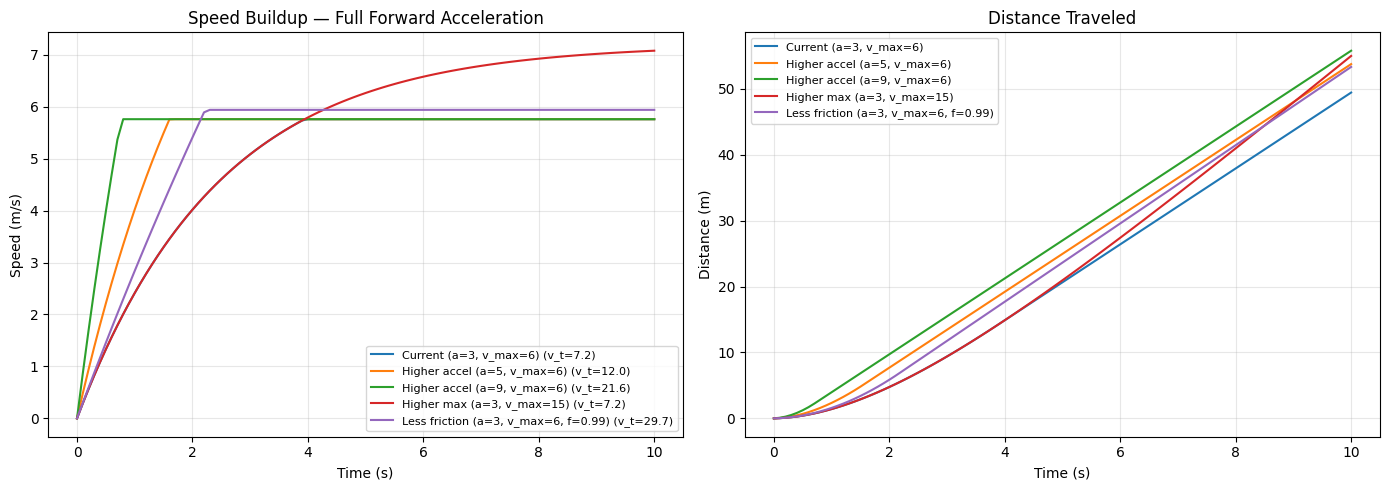

In [4]:
steps = 100
t = np.arange(steps + 1) * DT

configs = {
    "Current (a=3, v_max=6)": (3, 6, 0.96),
    "Higher accel (a=5, v_max=6)": (5, 6, 0.96),
    "Higher accel (a=9, v_max=6)": (9, 6, 0.96),
    "Higher max (a=3, v_max=15)": (3, 15, 0.96),
    "Less friction (a=3, v_max=6, f=0.99)": (3, 6, 0.99),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, (accel, max_spd, fric) in configs.items():
    vel, pos = simulate_1d(accel, max_spd, fric, DT, REF_DT, steps)
    v_t = terminal_velocity(accel, fric, DT, REF_DT)
    ax1.plot(t, vel, label=f"{label} (v_t={v_t:.1f})")
    ax2.plot(t, pos, label=label)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (m/s)")
ax1.set_title("Speed Buildup — Full Forward Acceleration")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Distance (m)")
ax2.set_title("Distance Traveled")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
steps = 100
t = np.arange(steps + 1) * DT

ang_configs = {
    "Current (α=π/8, ω_max=π/4)": (np.pi/8, np.pi/4, 0.95),
    "Faster turn (α=π/4, ω_max=π/2)": (np.pi/4, np.pi/2, 0.95),
    "Much faster (α=π/2, ω_max=π)": (np.pi/2, np.pi, 0.95),
    "Less ang friction (α=π/8, ω_max=π/4, f=0.98)": (np.pi/8, np.pi/4, 0.98),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, (ang_acc, max_w, ang_f) in ang_configs.items():
    ang_vel, angle = simulate_angular(ang_acc, max_w, ang_f, DT, REF_DT, steps)
    ax1.plot(t, np.degrees(ang_vel), label=label)
    ax2.plot(t, np.degrees(angle), label=label)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Angular Speed (°/s)")
ax1.set_title("Angular Speed Buildup — Max Turn")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.axhline(90, color="gray", linestyle="--", alpha=0.5, label="90°")
ax2.axhline(180, color="gray", linestyle=":", alpha=0.5, label="180°")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Rotation (°)")
ax2.set_title("Cumulative Rotation from Standstill")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
steps = 150
t = np.arange(steps + 1) * DT

def simulate_coastdown(start_speed, friction, dt, ref_dt, steps):
    vel = np.zeros(steps + 1)
    pos = np.zeros(steps + 1)
    vel[0] = start_speed
    for i in range(steps):
        v = vel[i] * friction ** (dt / ref_dt)
        if abs(v) < VELOCITY_THRESHOLD:
            v = 0.0
        vel[i + 1] = v
        pos[i + 1] = pos[i] + dt * v
    return vel, pos

def simulate_ang_coastdown(start_w, ang_friction, dt, ref_dt, steps):
    ang_vel = np.zeros(steps + 1)
    angle = np.zeros(steps + 1)
    ang_vel[0] = start_w
    for i in range(steps):
        w = ang_vel[i] * ang_friction ** (dt / ref_dt)
        if abs(w) < VELOCITY_THRESHOLD:
            w = 0.0
        ang_vel[i + 1] = w
        angle[i + 1] = angle[i] + dt * w
    return ang_vel, angle

c = CURRENT
v_max_eff = min(terminal_velocity(c["max_accel"], c["friction"], DT, REF_DT), c["max_speed"])
w_max_eff = min(terminal_velocity(c["max_ang_accel"], c["ang_friction"], DT, REF_DT), c["max_ang_speed"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Linear coastdown
for fric, label in [(0.90, "f=0.90"), (0.93, "f=0.93"), (0.96, "f=0.96 (current)"), (0.99, "f=0.99")]:
    vel, pos = simulate_coastdown(v_max_eff, fric, DT, REF_DT, steps)
    axes[0, 0].plot(t, vel, label=label)
    axes[0, 1].plot(t, pos, label=label)

axes[0, 0].set_xlabel("Time (s)"); axes[0, 0].set_ylabel("Speed (m/s)")
axes[0, 0].set_title(f"Linear Coast-Down from {v_max_eff:.1f} m/s")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel("Time (s)"); axes[0, 1].set_ylabel("Distance (m)")
axes[0, 1].set_title("Glide Distance"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Angular coastdown
for ang_f, label in [(0.90, "f=0.90"), (0.93, "f=0.93"), (0.95, "f=0.95 (current)"), (0.98, "f=0.98")]:
    ang_vel, angle = simulate_ang_coastdown(w_max_eff, ang_f, DT, REF_DT, steps)
    axes[1, 0].plot(t, np.degrees(ang_vel), label=label)
    axes[1, 1].plot(t, np.degrees(angle), label=label)

axes[1, 0].set_xlabel("Time (s)"); axes[1, 0].set_ylabel("Angular Speed (°/s)")
axes[1, 0].set_title(f"Angular Coast-Down from {np.degrees(w_max_eff):.1f}°/s")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_xlabel("Time (s)"); axes[1, 1].set_ylabel("Rotation (°)")
axes[1, 1].set_title("Overshoot Rotation"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def simulate_uturn(max_accel, max_speed, friction, max_ang_accel, max_ang_speed, ang_friction, dt, ref_dt, max_steps=500):
    """Simulate a U-turn: player at max speed, rotates 180°, then accelerates forward in new direction."""
    v_term = min(terminal_velocity(max_accel, friction, dt, ref_dt), max_speed)

    speed = np.zeros(max_steps + 1)
    orientation = np.zeros(max_steps + 1)
    pos_x = np.zeros(max_steps + 1)
    ang_vel = np.zeros(max_steps + 1)

    speed[0] = v_term
    orientation[0] = 0.0

    turned = False
    turn_step = None

    for i in range(max_steps):
        if not turned and orientation[i] < np.pi:
            # Phase 1: coast (no forward accel) + rotate
            accel = 0.0
            ang_acc = max_ang_accel
        else:
            if not turned:
                turned = True
                turn_step = i
            accel = max_accel
            ang_acc = 0.0

        # Angular update
        w = ang_vel[i] + dt * ang_acc
        w = np.clip(w, -max_ang_speed, max_ang_speed)
        w *= ang_friction ** (dt / ref_dt)
        if abs(w) < VELOCITY_THRESHOLD:
            w = 0.0
        ang_vel[i + 1] = w
        orientation[i + 1] = orientation[i] + dt * w

        # Linear update (acceleration along current orientation)
        forward_accel = accel
        vx_accel = np.cos(orientation[i]) * forward_accel
        vy_accel = np.sin(orientation[i]) * forward_accel

        vx = speed[i] * np.cos(orientation[i])
        vy = speed[i] * np.sin(orientation[i])

        # Actually we track scalar speed + orientation. Let's use world-frame velocity.
        if i == 0:
            vx_world = v_term  # initially moving in +x direction
            vy_world = 0.0
        else:
            vx_world = _vx
            vy_world = _vy

        vx_world += dt * vx_accel
        vy_world += dt * vy_accel
        spd = np.sqrt(vx_world**2 + vy_world**2)
        if max_speed and spd > max_speed:
            vx_world *= max_speed / spd
            vy_world *= max_speed / spd
            spd = max_speed
        vx_world *= friction ** (dt / ref_dt)
        vy_world *= friction ** (dt / ref_dt)
        spd = np.sqrt(vx_world**2 + vy_world**2)
        if spd < VELOCITY_THRESHOLD:
            vx_world = vy_world = 0.0
            spd = 0.0

        _vx, _vy = vx_world, vy_world
        speed[i + 1] = spd
        pos_x[i + 1] = pos_x[i] + dt * vx_world

        # Check if we've completed the maneuver (moving in -x direction at decent speed)
        if turned and i > turn_step + 10 and spd > 0.5 * v_term:
            final_step = i + 1
            break
    else:
        final_step = max_steps

    return speed[:final_step+1], orientation[:final_step+1], pos_x[:final_step+1], turn_step, final_step

uturn_configs = {
    "Current": dict(max_accel=3, max_speed=6, friction=0.96, max_ang_accel=np.pi/8, max_ang_speed=np.pi/4, ang_friction=0.95),
    "Faster turn (α=π/4)": dict(max_accel=3, max_speed=6, friction=0.96, max_ang_accel=np.pi/4, max_ang_speed=np.pi/2, ang_friction=0.95),
    "Faster accel (a=5)": dict(max_accel=5, max_speed=6, friction=0.96, max_ang_accel=np.pi/8, max_ang_speed=np.pi/4, ang_friction=0.95),
    "Both faster": dict(max_accel=5, max_speed=6, friction=0.96, max_ang_accel=np.pi/4, max_ang_speed=np.pi/2, ang_friction=0.95),
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

for label, params in uturn_configs.items():
    spd, ori, px, ts, fs = simulate_uturn(**params, dt=DT, ref_dt=REF_DT)
    t = np.arange(len(spd)) * DT
    ax1.plot(t, spd, label=f"{label} ({fs*DT:.1f}s)")
    ax2.plot(t, np.degrees(ori), label=label)
    ax3.plot(t, px, label=label)

ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Speed (m/s)")
ax1.set_title("U-Turn: Speed"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.axhline(180, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Orientation (°)")
ax2.set_title("U-Turn: Orientation"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3.set_xlabel("Time (s)"); ax3.set_ylabel("X Position (m)")
ax3.set_title("U-Turn: Position Drift"); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
accels = [1, 3, 5, 9]
ang_accels = [np.pi/16, np.pi/8, np.pi/4, np.pi/2]
ang_accel_labels = ["π/16", "π/8", "π/4", "π/2"]

friction = 0.96
ang_friction = 0.95

# Compute metrics for each combo
t_max_speed = np.zeros((len(accels), len(ang_accels)))
t_180 = np.zeros((len(accels), len(ang_accels)))
t_uturn = np.zeros((len(accels), len(ang_accels)))

for i, accel in enumerate(accels):
    for j, ang_acc in enumerate(ang_accels):
        max_spd = 6
        max_w = ang_acc * 4  # keep max_ang_speed proportional (4x the accel)

        t_ms = time_to_fraction(0.9, accel, max_spd, friction, DT, REF_DT)
        t_max_speed[i, j] = t_ms if t_ms else float('nan')

        t_rot = time_to_angle(180, ang_acc, max_w, ang_friction, DT, REF_DT)
        t_180[i, j] = t_rot if t_rot else float('nan')

        _, _, _, _, fs = simulate_uturn(accel, max_spd, friction, ang_acc, max_w, ang_friction, DT, REF_DT)
        t_uturn[i, j] = fs * DT

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(axes, [t_max_speed, t_180, t_uturn],
                            ["Time to 90% Max Speed (s)", "Time to 180° Turn (s)", "U-Turn Total Time (s)"]):
    im = ax.imshow(data, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(ang_accels)))
    ax.set_xticklabels(ang_accel_labels)
    ax.set_yticks(range(len(accels)))
    ax.set_yticklabels(accels)
    ax.set_xlabel("Max Angular Accel (rad/s²)")
    ax.set_ylabel("Max Linear Accel (m/s²)")
    ax.set_title(title)
    for ii in range(len(accels)):
        for jj in range(len(ang_accels)):
            ax.text(jj, ii, f"{data[ii, jj]:.1f}", ha="center", va="center", fontsize=9,
                    color="white" if data[ii, jj] > np.nanmedian(data) else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# Friction sweep
print("\n=== Friction Factor Impact (accel=3, ang_accel=π/8) ===\n")
print(f"{'Friction':>10} {'v_terminal':>12} {'t_90% speed':>13} {'Stop dist':>11} {'Stop time':>11}")
for f in [0.90, 0.93, 0.96, 0.99]:
    v_t = terminal_velocity(3, f, DT, REF_DT)
    v_eff = min(v_t, 6)
    t90 = time_to_fraction(0.9, 3, 6, f, DT, REF_DT)
    sd, st = stopping_distance(v_eff, f, DT, REF_DT)
    print(f"{f:>10.2f} {v_t:>10.1f} m/s {t90:>10.1f} s {sd:>9.1f} m {st:>9.1f} s")

## Tuning Guidelines

**What makes good movement feel:**
- **Acceleration to max speed**: 0.5–1.5s (too fast = twitchy, too slow = sluggish)
- **180° turn from standstill**: 1.0–2.5s (too fast = orientation is irrelevant, too slow = frustrating)
- **U-turn total time**: 2.0–4.0s (should be costly enough that positioning matters)
- **Stopping glide**: 1–5m (some momentum, not ice skating)

**Knobs to adjust in `env/config.py`:**
```python
PLAYER_MAX_SPEED = ?              # Terminal speed cap (m/s)
PLAYER_MAX_ACCELERATION = ?       # Forward thrust (m/s²)
PLAYER_MAX_ANGULAR_SPEED = ?      # Turn rate cap (rad/s)
PLAYER_MAX_ANGULAR_ACCELERATION = ? # Turn thrust (rad/s²)
PLAYER_FRICTION_FACTOR = ?        # Linear drag per step [0.90–0.99]
ANGULAR_FRICTION_FACTOR = ?       # Rotational drag per step [0.90–0.99]
```

Use the plots and heatmaps above to pick values, then run the simulation (`python -m env.simulation`) to feel them in action.